alpha: 0.05066059182116889
Выберите метод:
1 - явная конечно-разностная схема
2 - неявная конечно-разностная схема
3 - схема Кранка-Николсона
1
Выберите уровень апроксимации:
1 - двухточечная аппроксимация с первым порядком
2 - трехточечная аппроксимация со вторым порядком
3 - двухточечная аппроксимация со вторым порядком
1


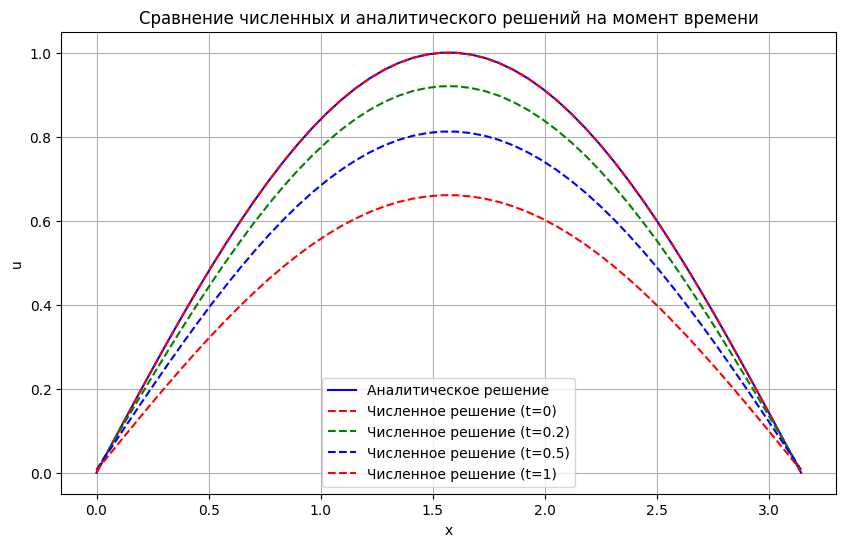

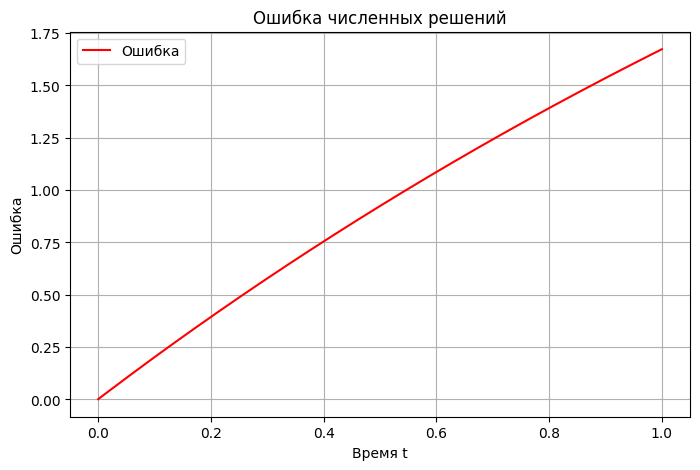

Максимальная ошибка: 1.672566743799242

Хотите выполнить еще один расчет?
1 - Да
2 - Нет (выход)
1


alpha: 0.05066059182116889
Выберите метод:
1 - явная конечно-разностная схема
2 - неявная конечно-разностная схема
3 - схема Кранка-Николсона
2
Выберите уровень апроксимации:
1 - двухточечная аппроксимация с первым порядком
2 - трехточечная аппроксимация со вторым порядком
3 - двухточечная аппроксимация со вторым порядком
2


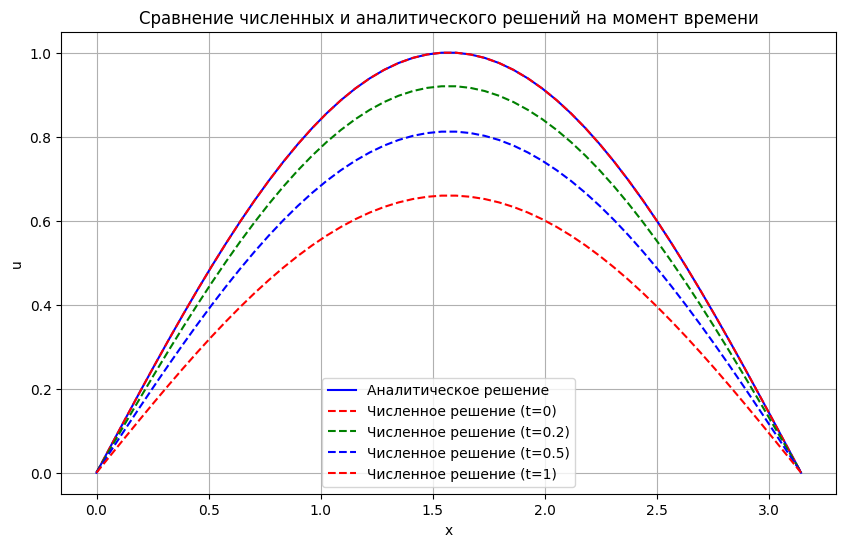

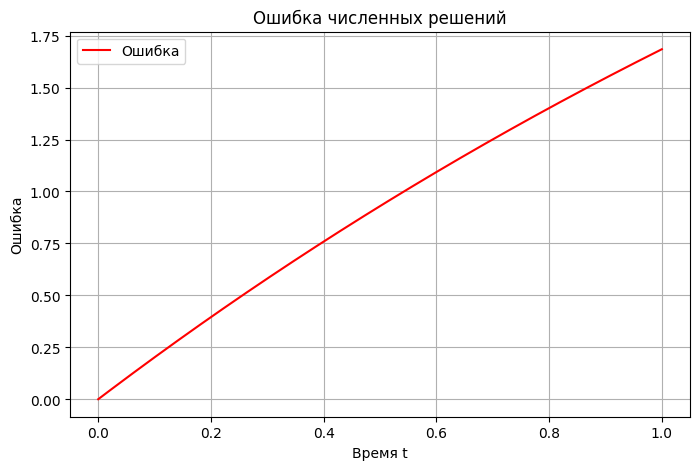

Максимальная ошибка: 1.6848199516495703

Хотите выполнить еще один расчет?
1 - Да
2 - Нет (выход)
1


alpha: 0.05066059182116889
Выберите метод:
1 - явная конечно-разностная схема
2 - неявная конечно-разностная схема
3 - схема Кранка-Николсона
3
Выберите уровень апроксимации:
1 - двухточечная аппроксимация с первым порядком
2 - трехточечная аппроксимация со вторым порядком
3 - двухточечная аппроксимация со вторым порядком
3


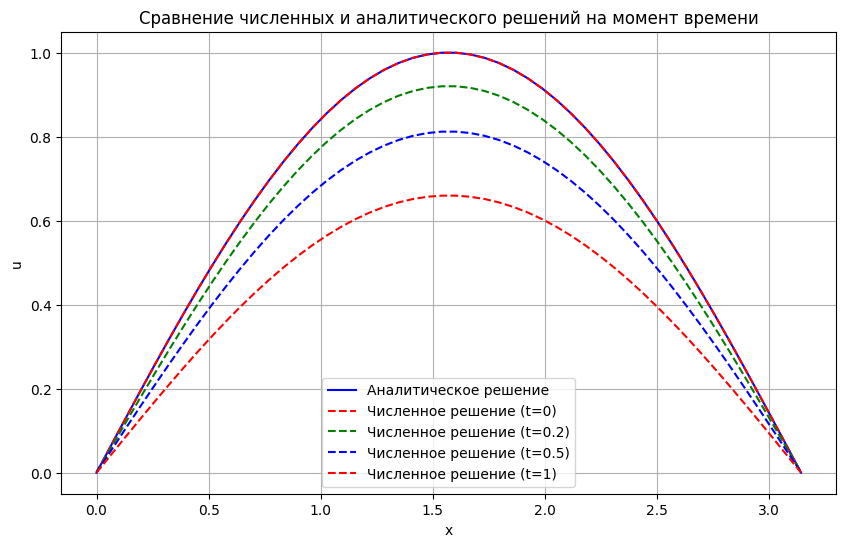

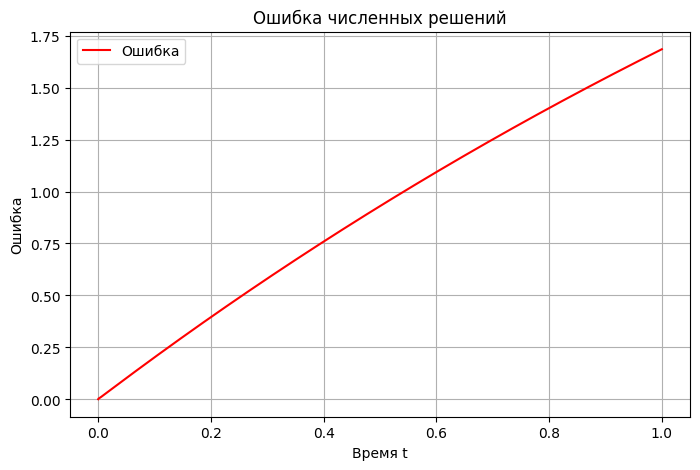

Максимальная ошибка: 1.6849613494083213

Хотите выполнить еще один расчет?
1 - Да
2 - Нет (выход)
2
Программа завершена.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

#Аналитическое решение
def analyt_func(x, t, a):
    return np.exp(-a * t) * np.sin(x)

# Начальные условия
def initial_condition(x):
    return np.sin(x)

# Явная схема
def explicit_scheme(Nx, Nt, dx, dt, x, t, a, al):
    u = np.zeros((Nt, Nx))
    u[0, :] = np.array([initial_condition(xi) for xi in x])

    for n in range(0, Nt-1):
        for j in range(1, Nx-1):
            u[n+1, j] = u[n, j] + ((a * dt) * (u[n, j+1] - 2*u[n, j] + u[n, j-1])) / (dx ** 2)

        if al == 1:
            u[n+1, 0] = u[n+1, 1] + (np.exp(-a * t[n+1])) * (0 - dx)
            u[n+1, Nx-1] = u[n+1, Nx-2] + (-np.exp(-a * t[n+1])) * dx
        if al == 2:
            u[n+1, 0] = (2*a/dx * u[n+1, 1] + dx/dt * u[n, 0] - 2*a*np.exp(-a * t[n+1]))/(2*a/dx + dx/dt)
            u[n+1, Nx-1] = (2*a/dx * u[n+1, Nx-2] + dx/dt * u[n, Nx-1] - 2*a*np.exp(-a * t[n+1]))/(2*a/dx + dx/dt)
        if al == 3:
            u[n+1, 0] = u[n+1, 2] + (np.exp(-a * t[n+1])) * (0 - 2*dx)
            u[n+1, Nx-1] = u[n+1, Nx-3] + (-np.exp(-a * t[n+1])) * 2*dx

    return u

# Неявная схема
def implicit_scheme(Nx, Nt, alpha, x, t, a, al, dx, dt):
    u = np.zeros((Nt, Nx))
    u[0, :] = np.array([initial_condition(xi) for xi in x])

    A = np.zeros((Nx-2, Nx-2))
    for i in range(Nx-2):
        A[i, i] = 1 + 2 * alpha
        if i > 0:
            A[i, i-1] = -alpha
        if i < Nx-3:
            A[i, i+1] = -alpha

    for n in range(0, Nt-1):
        b = u[n, 1:-1]
        b[0] += alpha * u[n+1, 0]
        b[-1] += alpha * u[n+1, -1]
        u[n+1, 1:-1] = solve(A, b)

        if al == 1:
            u[n+1, 0] = u[n+1, 1] + (np.exp(-a * t[n+1])) * (0 - dx)
            u[n+1, Nx-1] = u[n+1, Nx-2] + (-np.exp(-a * t[n+1])) * dx
        if al == 2:
            u[n+1, 0] = (2*a/dx * u[n+1, 1] + dx/dt * u[n, 0] - 2*a*np.exp(-a * t[n+1]))/(2*a/dx + dx/dt)
            u[n+1, Nx-1] = (2*a/dx * u[n+1, Nx-2] + dx/dt * u[n, Nx-1] - 2*a*np.exp(-a * t[n+1]))/(2*a/dx + dx/dt)
        if al == 3:
            u[n+1, 0] = u[n+1, 2] + (np.exp(-a * t[n+1])) * (0 - 2*dx)
            u[n+1, Nx-1] = u[n+1, Nx-3] + (-np.exp(-a * t[n+1])) * 2*dx

    return u

# Схема Кранка-Николсона
def crank_nicolson_scheme(Nx, Nt, alpha, x, t, a, al, dx, dt):
    u = np.zeros((Nt, Nx))
    u[0, :] = np.array([initial_condition(xi) for xi in x])

    A = np.zeros((Nx-2, Nx-2))
    B = np.zeros((Nx-2, Nx-2))
    for i in range(Nx-2):
        A[i, i] = 1 + alpha
        B[i, i] = 1 - alpha
        if i > 0:
            A[i, i-1] = -alpha / 2
            B[i, i-1] = alpha / 2
        if i < Nx-3:
            A[i, i+1] = -alpha / 2
            B[i, i+1] = alpha / 2

    for n in range(0, Nt-1):
        b = B @ u[n, 1:-1]
        b[0] += alpha / 2 * u[n+1, 0]
        b[-1] += alpha / 2 * u[n+1, -1]
        u[n+1, 1:-1] = solve(A, b)

        if al == 1:
            u[n+1, 0] = u[n+1, 1] + (np.exp(-a * t[n+1])) * (0 - dx)
            u[n+1, Nx-1] = u[n+1, Nx-2] + (-np.exp(-a * t[n+1])) * dx
        if al == 2:
            u[n+1, 0] = (2*a/dx * u[n+1, 1] + dx/dt * u[n, 0] - 2*a*np.exp(-a * t[n+1]))/(2*a/dx + dx/dt)
            u[n+1, Nx-1] = (2*a/dx * u[n+1, Nx-2] + dx/dt * u[n, Nx-1] - 2*a*np.exp(-a * t[n+1]))/(2*a/dx + dx/dt)
        if al == 3:
            u[n+1, 0] = u[n+1, 2] + (np.exp(-a * t[n+1])) * (0 - 2*dx)
            u[n+1, Nx-1] = u[n+1, Nx-3] + (-np.exp(-a * t[n+1])) * 2*dx

    return u

def run_calculation():
    a = 0.4
    L = np.pi
    T = 1.0
    Nx = 50
    dx = L / (Nx)
    dt = 0.0005
    Nt = int(T / dt)
    x = np.linspace(0, L, Nx)
    t = np.linspace(0, T, Nt)
    alpha = (a * dt) / (dx ** 2)

    print(f"alpha: {alpha}")
    print("Выберите метод:\n"
          "1 - явная конечно-разностная схема\n"
          "2 - неявная конечно-разностная схема\n"
          "3 - схема Кранка-Николсона")
    method = int(input())

    print("Выберите уровень апроксимации:\n"
          "1 - двухточечная аппроксимация с первым порядком\n"
          "2 - трехточечная аппроксимация со вторым порядком\n"
          "3 - двухточечная аппроксимация со вторым порядком")
    al = int(input())

    if method == 1:
        U = explicit_scheme(Nx, Nt, dx, dt, x, t, a, al)
    elif method == 2:
        U = implicit_scheme(Nx, Nt, alpha, x, t, a, al, dx, dt)
    elif method == 3:
        U = crank_nicolson_scheme(Nx, Nt, alpha, x, t, a, al, dx, dt)
    else:
        print("Неверный выбор метода")
        return

    # Вычисляем аналитическое решение для всех моментов времени
    u_analytical = [analyt_func(xi, 0, a) for xi in x]

    plt.figure(figsize=(10, 6))
    plt.plot(x, u_analytical, label=f'Аналитическое решение', linestyle='-', color='b')
    plt.plot(x, U[0, :], label=f'Численное решение (t=0)', linestyle='--', color='r')
    plt.plot(x, U[int(0.2*Nt), :], label=f'Численное решение (t=0.2)', linestyle='--', color='g')
    plt.plot(x, U[int(0.5*Nt), :], label=f'Численное решение (t=0.5)', linestyle='--', color='b')
    plt.plot(x, U[int(Nt-2), :], label=f'Численное решение (t=1)', linestyle='--', color='r')
    plt.xlabel('x')
    plt.ylabel(f'u')
    plt.legend()
    plt.title(f'Сравнение численных и аналитического решений на момент времени')
    plt.grid(True)
    plt.show()

    # Вычисление ошибок для всех схем
    error = np.sqrt(np.sum((U - u_analytical)**2, axis=1))

    # Визуализация ошибок
    plt.figure(figsize=(8, 5))
    plt.plot(t, error, label='Ошибка', color='r')
    plt.xlabel('Время t')
    plt.ylabel('Ошибка')
    plt.legend()
    plt.title('Ошибка численных решений')
    plt.grid(True)
    plt.show()

    # Вывод максимальных ошибок для всех схем
    print(f"Максимальная ошибка: {np.max(error)}")

# Основной цикл программы
while True:
    run_calculation()
    print("\n" + "="*50)
    print("Хотите выполнить еще один расчет?")
    print("1 - Да")
    print("2 - Нет (выход)")
    choice = input()
    if choice == "2":
        break
    print("\n" + "="*50 + "\n")

print("Программа завершена.")